# I. TPI Tools

## Overview

The **Topographic Position Index (TPI)** compares the elevation (or bathymetry) of a center cell to the mean value of the surrounding neighborhood.

- **Positive TPI** → High point 
- **Negative TPI** → Low point 

### TPI Calculation

The TPI value for a cell at location (x, y) is calculated as:

$$
\text{TPI}_{x,y} = \text{E}_{x,y} - \text{WD}_{x,y}
$$

where: 

- $\text{E}_{x,y}$ = Bathymetry of center cell 
- $\text{WD}_{x,y}$ = Mean bathymetry of neighborhood

This produces a **TPI raster**, where each cell represents its relative elevation compared to its surrounding neighborhood.

---

## TPI Thresholds

### Bathymetric High Feature Threshold

A cell is classified as a **bathymetric high feature** when its TPI value exceeds the upper threshold:

$$
\text{TPI}_{T} = \text{TPI}_{m} + C_{\text{TPI}} \times \text{TPI}_{s}
$$

where:

- $\text{TPI}_{m}$ = Spatial mean of TPI values
- $\text{TPI}_{s}$ = Standard deviation of TPI values
- $C_{\text{TPI}}$ = TPI STD Scale parameter

### Bathymetric Low Feature Threshold

A cell is classified as a potential **bathymetric low feature** when its TPI value falls below the lower threshold:

$$
\text{TPI}_{T} = \text{TPI}_{m} - C_{\text{TPI}} \times \text{TPI}_{s}
$$

---

## Workflow 

1. Compute the TPI raster (Equation 1).
2. Calculate the spatial mean and standard deviation of TPI values.
3. Determine the high and low feature thresholds (Equations 2 & 3).
4. Select cells whose TPI values are:
   - Greater than the high-feature threshold, or
   - Less than the low-feature threshold.
5. Convert the selected regions into polygons.
6. Remove polygons whose area is smaller than the specified area threshold.
7. The remaining polygons represent the final set of bathymetric high and low features.

---

## Result 

The workflow produces a set of polygon features representing:

- **Bathymetric high features** (positive anomalies)
- **Bathymetric low features** (negative anomalies)

These polygons can be used for feature classification and further geomorphological analysis.

# Load Bathymetry Data

First, we load the bathymetry raster into a NumPy array.

Any No Data values are converted to NaN so they can be ignored during calculations. We also extract information about the raster's coordinate system and cell size for later use.

In [2]:
# Imports
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker

import rasterio as rio
from rasterio.plot import plotting_extent
from scipy.ndimage import generic_filter

# Import raster polygonization utilities
import rasterio.features as rfeatures

from shapely.geometry import shape

import geopandas as gpd

formatter = mticker.FuncFormatter(lambda x, pos: f"{int(x):,}")

In [3]:
# Read in data
def load_raster(path):
    with rio.open(path) as src:
        arr = src.read(1, masked=True).astype(float).filled(np.nan)
        return arr, src.transform, src.crs


bathy_path = Path("../data/gifford_bathy.tif")

bathy, transform, crs = load_raster(bathy_path)
extent = plotting_extent(bathy, transform)

dx = abs(transform.a)
dy = abs(transform.e)

print("shape:", bathy.shape)
print("crs:", crs)
print("resolution:", (dx, dy))
print("depth range:", (np.nanmin(bathy), np.nanmax(bathy)))

shape: (835, 914)
crs: EPSG:32757
resolution: (50.0, 50.0)
depth range: (np.float64(-3221.864990234375), np.float64(-255.59681701660156))


---

# Choosing a TPI Radius

One of the most important parameters in the TPI workflow is the **TPI Circle Radius**.

The radius determines the size of the neighborhood used to calculate the local bathymetric mean and therefore controls the scale of features that can be identified.

According to the paper, a useful rule of thumb is to select a radius that is slightly larger than the largest feature you want to map.

The bathymetry raster used in this example has a cell size of 50 m, meaning each raster cell represents a 50 m × 50 m area.

Approximate feature scales associated with several radius values are shown below:

| Radius (cells) | Approximate Feature Scale |
|---------------|--------------------------|
| 5 | 500 m |
| 10 | 1000 m |
| 25 | 2500 m |

Because seabed features occur at many different scales, TPI is often calculated using multiple radius values and the results are compared.

In this example, TPI will be calculated using three different neighborhood sizes to demonstrate how the radius influences the resulting TPI raster.

---

# Calculating TPI

Following the method described in the paper, TPI is computed as the difference between the bathymetry value at a center cell and the mean bathymetry within a circular neighborhood.

$$
TPI_{x,y} = E_{x,y} - WD_{x,y}
$$

where:

- $E_{x,y}$ is the bathymetry value at the center cell
- $WD_{x,y}$ is the mean bathymetry within a circular neighborhood

The neighborhood size is controlled by the **TPI Circle Radius** parameter, expressed in raster cells.

After calculating the TPI raster, the spatial mean and standard deviation are used to define thresholds for identifying bathymetric highs and lows.

The function below implements the TPI raster calculation described in Step 1 of the workflow.

In [4]:
def calculate_tpi(bathy, radius_cells):

    y, x = np.ogrid[
        -radius_cells:radius_cells + 1,
        -radius_cells:radius_cells + 1
    ]

    footprint = (x**2 + y**2) <= radius_cells**2

    def tpi_filter(values):
        center = values[len(values)//2]

        if np.isnan(center):
            return np.nan

        return center - np.nanmean(values)

    tpi = generic_filter(
        bathy,
        tpi_filter,
        footprint=footprint,
        mode="nearest"
    )

    return tpi, np.nanmean(tpi), np.nanstd(tpi)

## How the Function Works

For each cell in the raster, the function:

1. Creates a circular neighborhood around the cell.
2. Calculates the mean bathymetry within that neighborhood.
3. Subtracts the neighborhood mean from the center-cell bathymetry.
4. Stores the result as a TPI value.

The output is a new raster where each cell describes its relative position compared to its surroundings.

---

# Calculating TPI Thresholds

Once the TPI raster has been calculated, we can identify potential bathymetric highs and lows using threshold values.

These thresholds are based on the mean and standard deviation of all TPI values in the raster.

In [5]:
def calculate_tpi_thresholds(tpi_mean, tpi_std, std_scale=1.0):

    high = tpi_mean + std_scale * tpi_std
    low = tpi_mean - std_scale * tpi_std

    return high, low

---

# Calculate TPI

The following example calculates TPI using a user-defined neighborhood radius and computes the corresponding bathymetric high and low thresholds.

In [6]:
radius_values = [5, 10, 25]

tpi_results = {}

for r in radius_values:

    tpi, mean, std = calculate_tpi(bathy, r)
    high, low = calculate_tpi_thresholds(mean, std)

    tpi_results[r] = {
        "tpi": tpi,
        "mean": mean,
        "std": std,
        "high": high,
        "low": low
    }

    print(f"Radius {r}: mean={mean:.3f}, std={std:.3f}")

Radius 5: mean=-0.008, std=10.611
Radius 10: mean=-0.030, std=17.356
Radius 25: mean=-0.236, std=37.611


---

# Comparing TPI at Multiple Scales

The paper recommends calculating TPI using multiple neighborhood sizes because different radius values highlight different types of seabed features.

Smaller radii emphasize local-scale bathymetric variation, while larger radii emphasize broader geomorphic structures.

The maps below compare TPI calculated using three different neighborhood sizes.

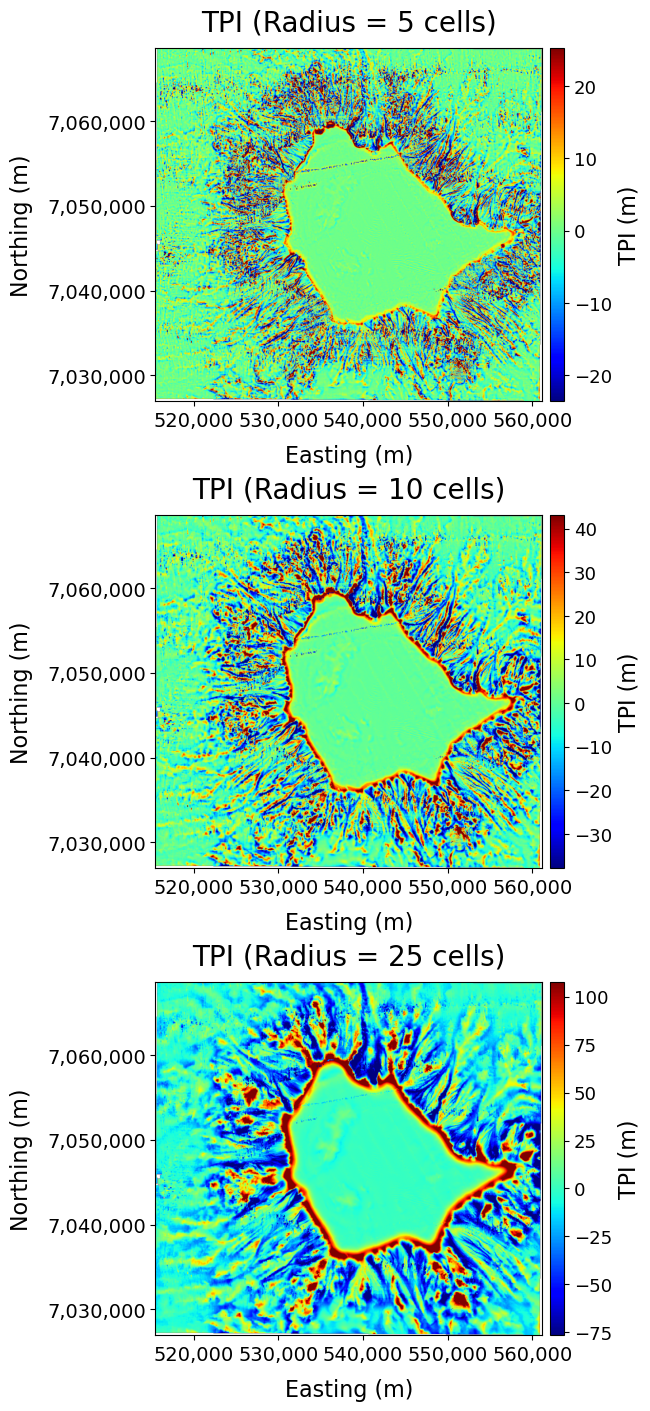

In [7]:
fig, axes = plt.subplots(
    len(radius_values),
    1,                      # stacked layout
    figsize=(14, 14),       # tall figure for large maps
    constrained_layout=True
)

# If only one radius, ensure axes is iterable
if len(radius_values) == 1:
    axes = [axes]

for ax, r in zip(axes, radius_values):

    tpi = tpi_results[r]["tpi"]

    # Improve contrast per map
    vmin = np.nanpercentile(tpi, 2)
    vmax = np.nanpercentile(tpi, 98)

    im = ax.imshow(
        tpi,
        extent=extent,
        origin="upper",
        cmap="jet",   # more readable than jet
        vmin=vmin,
        vmax=vmax
    )

    
    ax.set_title(
        f"TPI (Radius = {r} cells)",
        fontsize=20,
        pad=12
    )

    
    ax.set_xlabel("Easting (m)", fontsize=16, labelpad=10)
    ax.set_ylabel("Northing (m)", fontsize=16, labelpad=10)

    
    ax.tick_params(
        axis="both",
        labelsize=14
    )

    ax.locator_params(nbins=6)

    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.5%", pad=0.08)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("TPI (m)", fontsize=16)
    cbar.ax.tick_params(labelsize=13)

plt.show()

---

# Select Radius for Threshold Demonstration 
We now focus on one scale (25 cells)

In [8]:
r = 25

tpi = tpi_results[r]["tpi"]
tpi_mean = tpi_results[r]["mean"]
tpi_std = tpi_results[r]["std"]

high_thresh = tpi_results[r]["high"]
low_thresh = tpi_results[r]["low"]

## Before Thresholding (Raw TPI Signal)

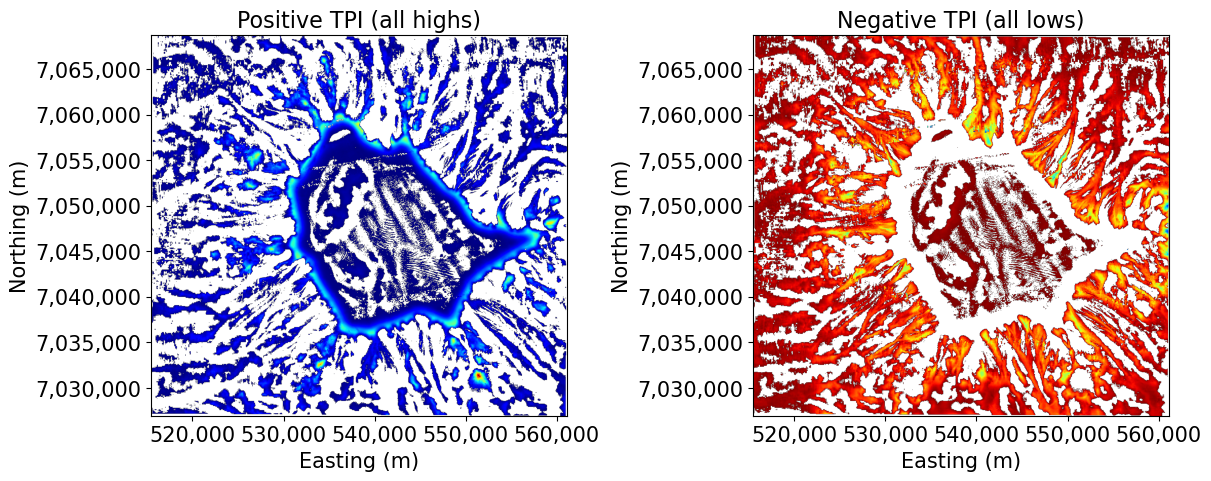

In [9]:
tpi_pos = np.where(tpi > 0, tpi, np.nan)
tpi_neg = np.where(tpi < 0, tpi, np.nan)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 8),
    constrained_layout=True
)

# Positive TPI
im0 = axes[0].imshow(
    tpi_pos,
    extent=extent,
    origin="upper",
    cmap="jet"
)

axes[0].set_title("Positive TPI (all highs)", fontsize=16)

# Negative TPI
im1 = axes[1].imshow(
    tpi_neg,
    extent=extent,
    origin="upper",
    cmap="jet"
)

axes[1].set_title("Negative TPI (all lows)", fontsize=16)


for ax in axes:

    ax.set_xlabel("Easting (m)", fontsize=15)
    ax.set_ylabel("Northing (m)", fontsize=15)

    ax.tick_params(labelsize=15)

    # Turn off scientific notation
    ax.ticklabel_format(style="plain", useOffset=False)

    # Apply formatter (full numbers with commas)
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

plt.show()

## After Thresholding (Feature Extraction)

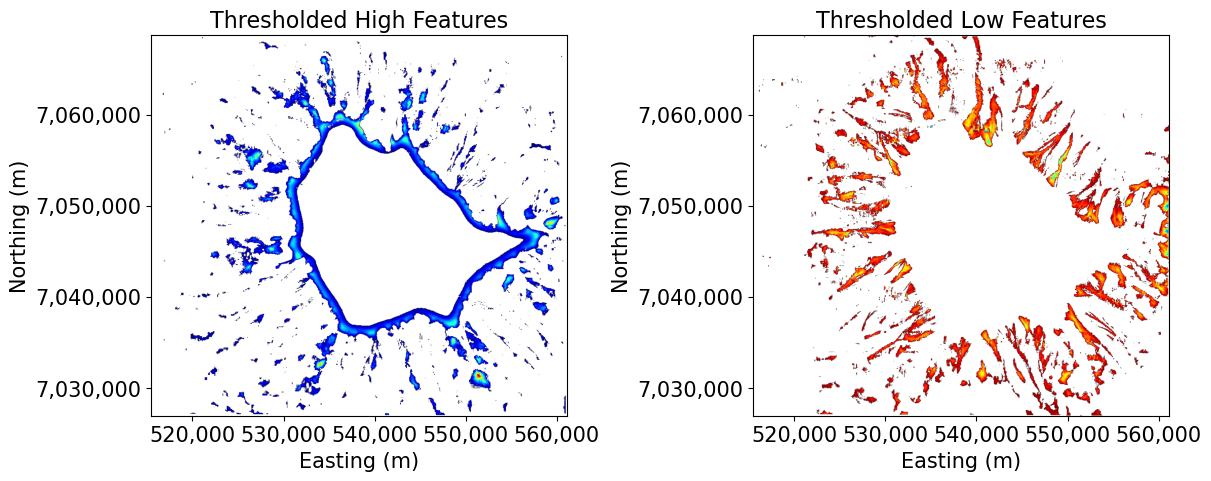

In [10]:
tpi_high = np.where(tpi > high_thresh, tpi, np.nan)
tpi_low  = np.where(tpi < low_thresh, tpi, np.nan)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 8),
    constrained_layout=True
)

axes[0].imshow(
    tpi_high,
    extent=extent,
    origin="upper",
    cmap="jet"
)

axes[0].set_title("Thresholded High Features", fontsize=16)

axes[1].imshow(
    tpi_low,
    extent=extent,
    origin="upper",
    cmap="jet"
)

axes[1].set_title("Thresholded Low Features", fontsize=16)

for ax in axes:

    ax.set_xlabel("Easting (m)", fontsize=15)
    ax.set_ylabel("Northing (m)", fontsize=15)

    ax.tick_params(labelsize=15)

    
    ax.ticklabel_format(style="plain", useOffset=False)

    
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    
    ax.locator_params(nbins=5)

plt.show()

## Why Thresholding Matters
The raw TPI raster shows all deviations from local mean bathymetry.

Thresholding isolates only the strongest positive and negative anomalies.

This reduces noise and highlights features that are more likely to represent meaningful geomorphology.

- Small radius → local terrain variation  
- Medium radius → intermediate seabed structures  
- Large radius → broad geomorphic features  

Thresholding further refines these results by isolating only strong deviations from the local mean.

Together, radius selection and thresholding control both the scale and sensitivity of feature detection.

---

# Interpreting the Results

The results show how TPI changes depending on the size of the neighborhood used in the calculation.

Smaller radii highlight fine-scale variations in the seafloor. These often appear as small patches of positive and negative values.

As the radius increases, the TPI surface becomes smoother and begins to emphasize broader geomorphic structures rather than local variation.

After applying thresholds, only the strongest positive and negative deviations remain. These areas are more likely to represent meaningful bathymetric features such as ridges, depressions, or mounds.

Overall, the results show that:

- Radius controls the *scale* of features being detected  
- Thresholding controls the *strength* of features being kept  

Different combinations of these parameters will highlight different aspects of the seafloor.

---

# What the Code Is Doing

This notebook follows the TPI workflow described in the paper step by step.

### 1. Load bathymetry data
The raster is loaded into a NumPy array. Missing values are converted to NaN so they do not affect calculations.

### 2. Define a neighborhood (radius)
For each cell, a circular neighborhood is created. The radius determines how much surrounding terrain is used to compute the local mean.

### 3. Compute TPI
For every cell:
- The mean bathymetry of the neighborhood is calculated
- This value is subtracted from the center cell
- The result is stored as the TPI value

This produces a raster of relative elevation (highs and lows).

### 4. Compute statistics
The mean and standard deviation of the TPI raster are calculated. These describe the overall distribution of values.

### 5. Apply thresholds
Using the paper’s method:
- Values above the upper threshold are classified as potential highs
- Values below the lower threshold are classified as potential lows

### 6. Visualize results
We compare:
- TPI at multiple spatial scales (different radii)
- Raw TPI values vs thresholded results

This helps show how both scale and thresholding affect feature detection.

---

# Connection to the Full Workflow

This notebook implements the core part of the TPI method described in the paper.

The full workflow consists of:

1. Calculating a TPI raster from bathymetry  
2. Computing statistical thresholds (mean and standard deviation)  
3. Identifying high and low anomalies using those thresholds  
4. Converting results into polygons  
5. Removing small or insignificant features based on area  

In this notebook, we complete steps 1–3 and visualize the results.

Steps 4–5 (polygon creation and filtering) are part of the full GIS-based workflow described in the paper but are not implemented here.

Despite this, the results still demonstrate the key idea of the method:

**TPI highlights relative terrain position, and thresholding extracts meaningful geomorphic features from that signal.**

---

# II. Polygonization of TPI Features

Polygonization converts raster-based feature classifications into vector polygons.

In this workflow, we take a thresholded TPI raster and extract connected regions of interest.

Each region becomes a polygon that represents a continuous geomorphic feature on the seabed.

This is important because:

- Raster data is cell-based and continuous  
- Polygons represent discrete, mappable features  
- Vector data allows measurement of area, shape, and spatial distribution  

This step completes the transition from **continuous surface analysis (TPI)** to **feature-based mapping**.

# How Polygonization Works

Polygonization groups connected raster cells into continuous shapes.

Each group becomes one polygon representing a seabed feature.

### Process:
- Neighboring True pixels are grouped together  
- Each group becomes a polygon  
- Raster data is converted into vector format  

This allows us to move from pixel-based analysis to spatial feature mapping.

In [11]:
with rio.open(bathy_path) as dataset:
    bathy = dataset.read(1, masked=True).astype(float).filled(np.nan)
    transform = dataset.transform
    crs = dataset.crs
    height = dataset.height
    width = dataset.width

extent = plotting_extent(bathy, transform)

dx = abs(transform.a)
dy = abs(transform.e)

print("shape:", bathy.shape)
print("crs:", crs)
print("cell size (resolution):", (dx, dy))
print("depth range:", (np.nanmin(bathy), np.nanmax(bathy)))
print("extent:", extent)

shape: (835, 914)
crs: EPSG:32757
cell size (resolution): (50.0, 50.0)
depth range: (np.float64(-3221.864990234375), np.float64(-255.59681701660156))
extent: (515475.0, 561175.0, 7026925.0, 7068675.0)


---

# Important Note on TPI Input

Although the raster loaded here is bathymetry, polygonization is performed on the **thresholded TPI mask**, not the raw bathymetry values.

TPI is first computed and thresholded to identify:

- High TPI regions (potential seabed highs)
- Low TPI regions (potential depressions)

Only these classified regions are converted into polygons.

---

# Thresholding TPI

We classify TPI values into:

- High features (TPI > upper threshold)
- Low features (TPI < lower threshold)

These thresholds are based on the mean and standard deviation of the TPI raster, following the paper.

In [12]:
# Ensure valid data mask
finite_tpi = np.isfinite(tpi)

# Threshold based on TPI (NOT bathymetry)
mask_high = finite_tpi & (tpi > high_thresh)
mask_low = finite_tpi & (tpi < low_thresh)

print("High candidate pixels:", int(mask_high.sum()))
print("Low candidate pixels:", int(mask_low.sum()))

High candidate pixels: 76959
Low candidate pixels: 81620


## Why We Use Masks

Masks convert continuous TPI values into simple binary regions.

- True = part of a feature  
- False = background  

This step is necessary because polygonization requires discrete regions, not continuous values.

---

# TPI Raster Visualization

The first output of the workflow is the TPI raster.

Each cell represents the difference between the bathymetry value at the center cell and the mean bathymetry of the surrounding neighborhood. Positive values indicate locations that are higher than their surroundings, while negative values indicate locations that are lower than their surroundings.

This raster forms the basis for all following feature extraction steps. Areas with large positive or negative TPI values are potential bathymetric features that may later be converted into polygons.


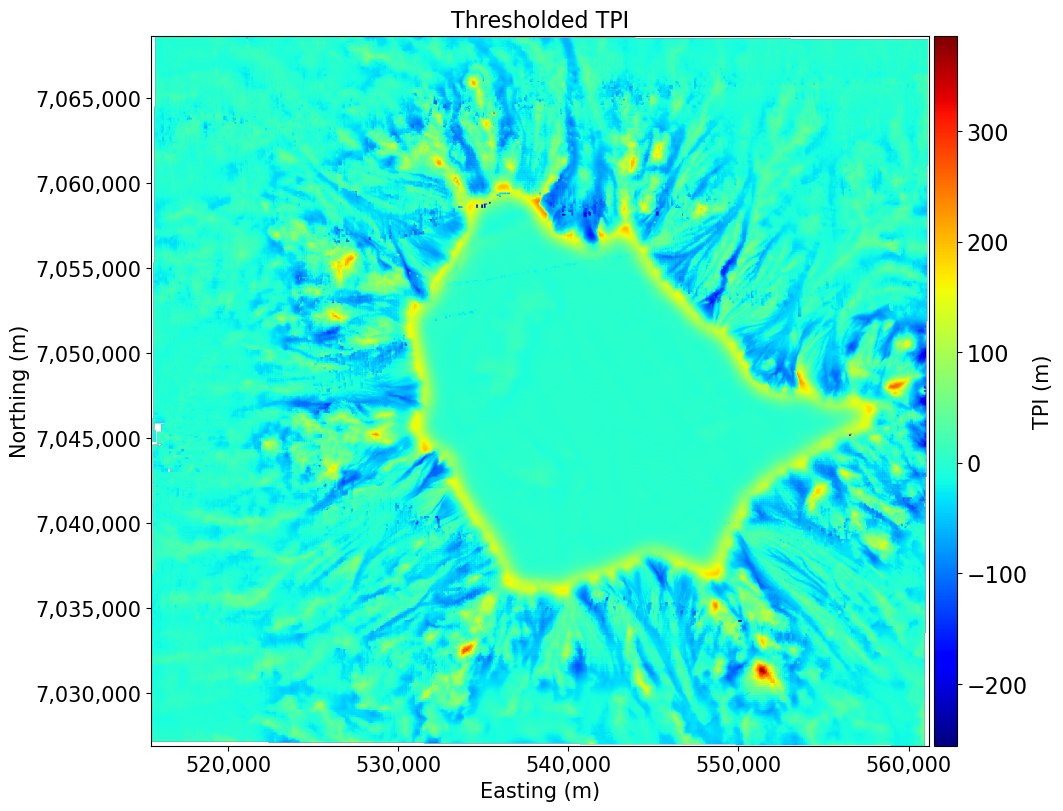

In [13]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

im = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

ax.set_title("Thresholded TPI", fontsize=16)
ax.set_xlabel("Easting (m)", fontsize=15)
ax.set_ylabel("Northing (m)", fontsize=15)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("TPI (m)", fontsize=15)

cbar.ax.tick_params(
    labelsize=16)

plt.show()

---

# Thresholded TPI Mask for High Features

The TPI raster contains continuous values, but the polygonization workflow requires discrete regions.

To identify candidate bathymetric features, threshold values are calculated using the mean and standard deviation of the TPI raster:

$$
\text{TPI}_{T} =
\text{TPI}_{m}
+
C_{\text{TPI}}
\times
\text{TPI}_{s}
$$

Cells exceeding the threshold are classified as potential bathymetric highs.

The figure below shows the resulting binary mask:

- White pixels represent cells that satisfy the threshold criterion.
- Black pixels represent cells that do not satisfy the threshold criterion.

This thresholding step reduces the continuous TPI raster to a set of candidate feature regions that can be converted into polygons.

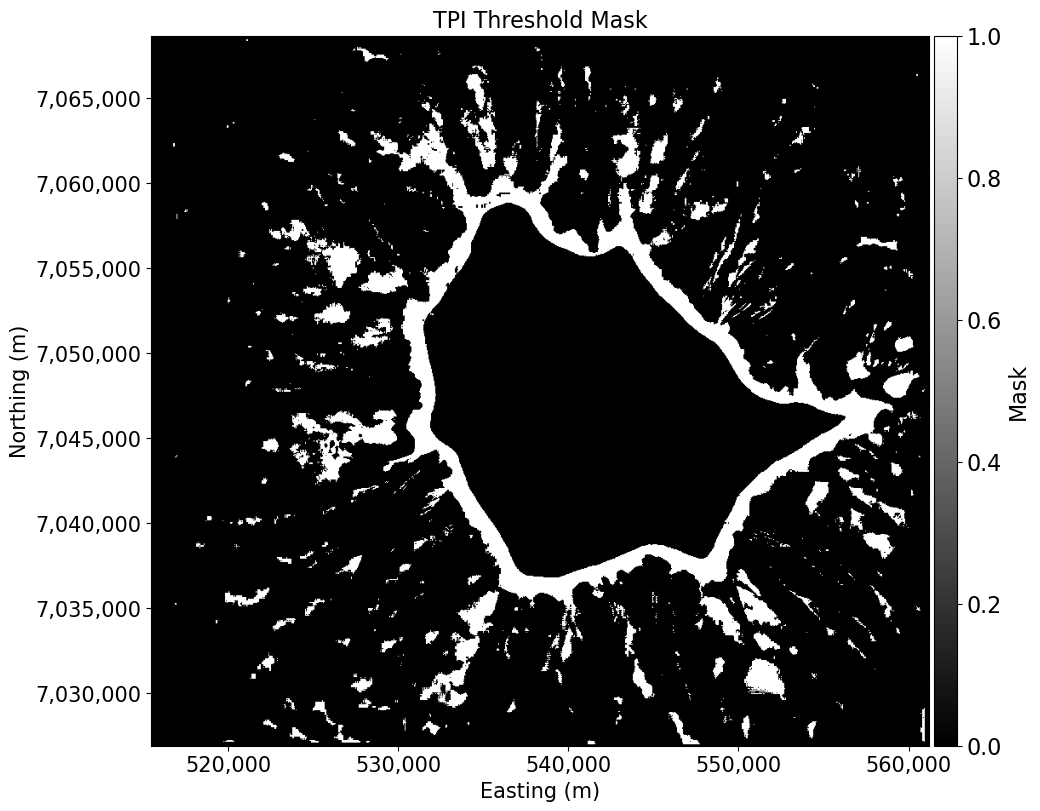

In [14]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

im = ax.imshow(
    mask_high.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1
)

ax.set_title("TPI Threshold Mask", fontsize=16)
ax.set_xlabel("Easting (m)", fontsize=15)
ax.set_ylabel("Northing (m)", fontsize=15)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Mask")
cbar.set_label(
    "Mask",
    fontsize=16)

cbar.ax.tick_params(
    labelsize=16)

plt.show()

---

# Polygonization Step

The binary mask is converted into vector polygons using raster-to-vector conversion.

Each polygon represents a connected group of pixels classified as a feature.

This process:

- Detects spatially continuous regions
- Converts raster cells into geometric shapes
- Produces mappable seabed feature outlines

In [43]:
shapes_high = rfeatures.shapes(
    mask_high.astype(np.uint8),
    transform=transform
)

geoms_high = [
    shape(geom)
    for geom, val in shapes_high
    if val == 1
]

gdf_high = gpd.GeoDataFrame(
    geometry=geoms_high,
    crs=crs
)

print("Polygons before filtering:", len(gdf_high))

Polygons before filtering: 1164


---

# Polygonized Features

After thresholding, contiguous groups of selected cells are converted into vector polygons.

Polygonization transforms raster regions into discrete feature boundaries that can be measured, filtered, and analyzed using standard GIS tools.

The figure below shows the extracted polygons overlaid on the TPI raster:

- Colored background: continuous TPI values.
- Black outlines: polygon boundaries generated from the thresholded mask.

This step bridges the gap between raster analysis and vector-based geomorphological mapping.

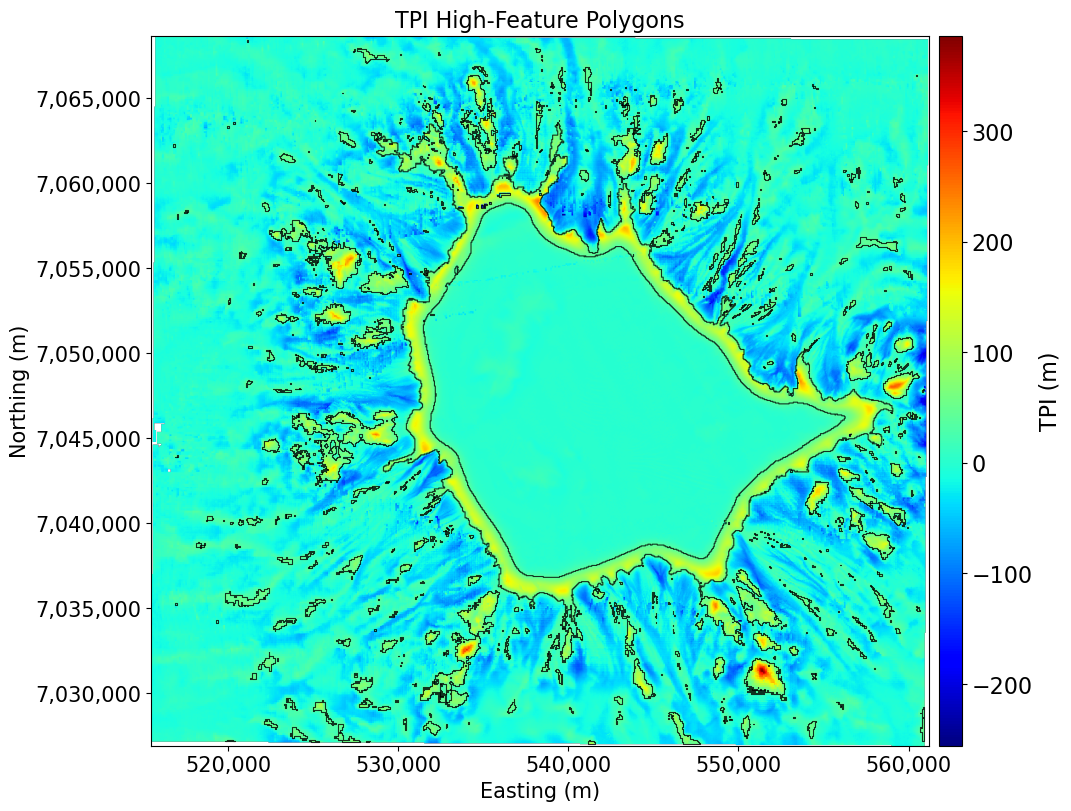

In [44]:
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# Display TPI raster as background
im = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

# Overlay polygon boundaries
if len(gdf_high):
    gdf_high.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

ax.set_title(
    "TPI High-Feature Polygons",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.1
)

cbar = fig.colorbar(
    im,
    cax=cax
)

cbar.set_label(
    "TPI (m)",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

## Selecting the Largest Features

After polygonization, the dataset may contain many polygons of different sizes.

Some polygons represent large geomorphic features, while others may be small isolated regions created by local variability in the TPI raster.

One way to reduce noise is to rank polygons by area and retain only the largest features in a process known as area threshold parameter masking. 

This approach highlights the most prominent bathymetric highs and lows in the study area and can simplify interpretation of the results.

In [49]:
# Area Filtering
# --------------

area_threshold_high = 25000.0  # approximately 10 pixels

gdf_high_filtered = gdf_high.copy()

if len(gdf_high_filtered):

    gdf_high_filtered["area"] = (
        gdf_high_filtered.area
    )

    gdf_high_filtered = (
        gdf_high_filtered[
            gdf_high_filtered["area"] > area_threshold_high
        ]
        .copy()
    )

print(
    "High-feature polygons before filtering:",
    len(gdf_high)
)

print(
    "High-feature polygons after filtering:",
    len(gdf_high_filtered)
)

print(
    "Polygons removed:",
    len(gdf_high) - len(gdf_high_filtered)
)

High-feature polygons before filtering: 1164
High-feature polygons after filtering: 245
Polygons removed: 919


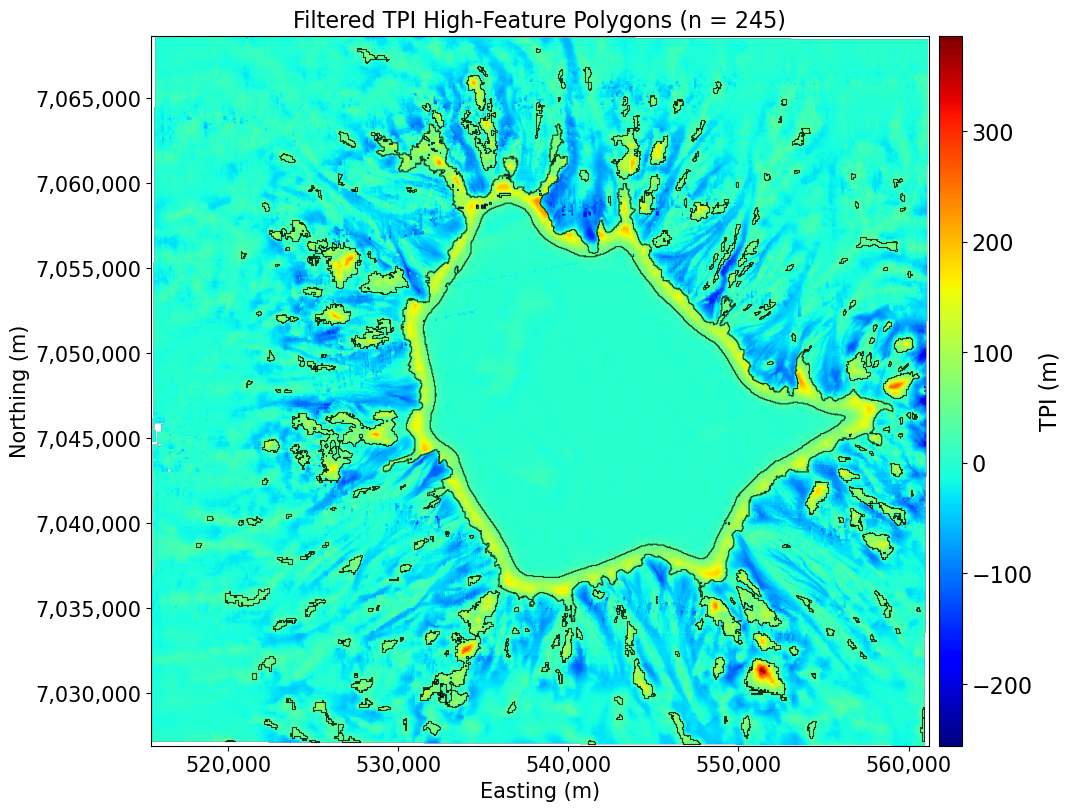

In [54]:
#%% Filtered High-Feature Polygon Visualization
# ---------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# TPI background
im = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

# Plot filtered polygons with thicker boundaries
if len(gdf_high_filtered):

    gdf_high_filtered.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

ax.set_title(
    f"Filtered TPI High-Feature Polygons (n = {len(gdf_high_filtered)})",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.1
)

cbar = fig.colorbar(
    im,
    cax=cax
)

cbar.set_label(
    "TPI (m)",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

# Threshold TPI Mask for Low Features

A similar workflow can be used to identify low features. 

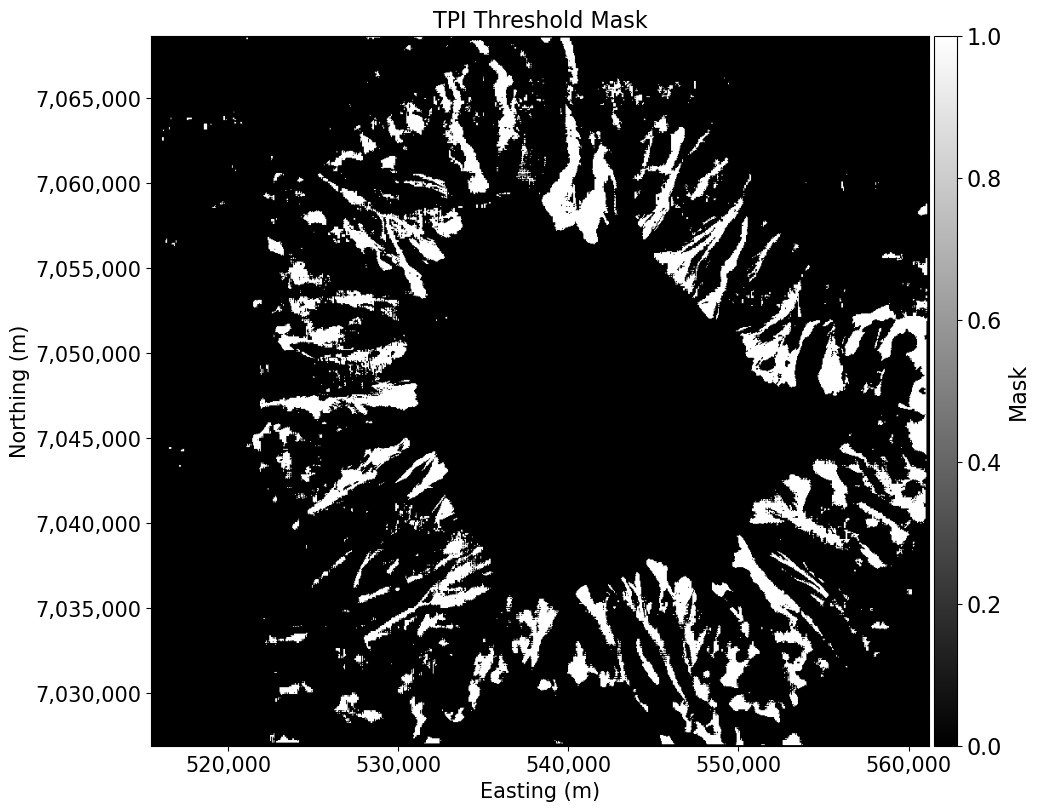

In [17]:
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

im_low = ax.imshow(
    mask_low.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1
)

ax.set_title(
    "TPI Threshold Mask",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.05
)

cbar = fig.colorbar(
    im_low,
    cax=cax
)

cbar.set_label(
    "Mask",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

In [32]:
shapes_all_low = rfeatures.shapes(
    mask_low.astype(np.uint8),
    transform=transform
)

geoms_all_low = [
    shape(geom)
    for geom, val in shapes_all_low
    if val == 1
]

gdf_low = gpd.GeoDataFrame(
    geometry=geoms_all_low,
    crs=crs
)

print("Polygons before filtering:", len(gdf_low))

Polygons before filtering: 1583


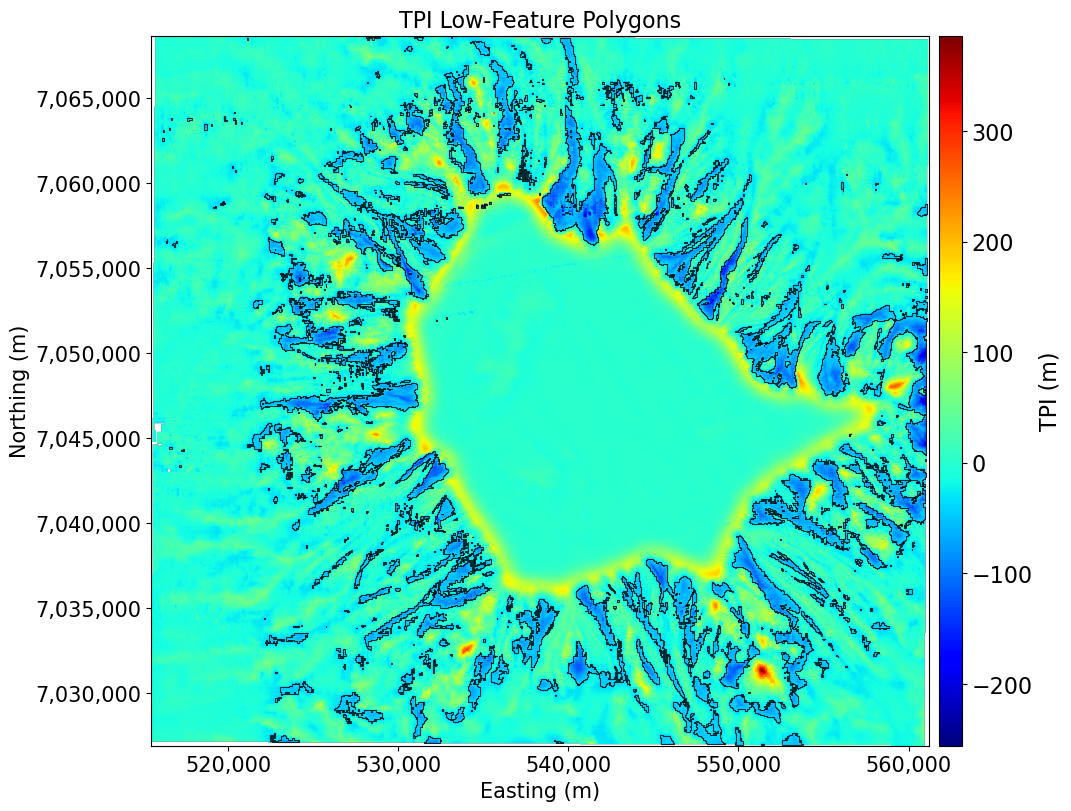

In [19]:
# Visualization 
fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# Display TPI raster as background
im_tpi = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

# Overlay LOW-feature polygon boundaries
if len(gdf_low):
    gdf_low.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

ax.set_title(
    "TPI Low-Feature Polygons",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.1
)

cbar = fig.colorbar(
    im_tpi,
    cax=cax
)

cbar.set_label(
    "TPI (m)",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

## Area Threshold Parameter Mask 

In [50]:
# Area Filtering
# --------------

area_threshold_low = 25000.0  # approximately 10 pixels

gdf_low_filtered = gdf_low.copy()

if len(gdf_low_filtered):

    gdf_low_filtered["area"] = (
        gdf_low_filtered.area
    )

    gdf_low_filtered = (
        gdf_low_filtered[
            gdf_low_filtered["area"] > area_threshold_low
        ]
        .copy()
    )

print(
    "Low-feature polygons before filtering:",
    len(gdf_low)
)

print(
    "Low-feature polygons after filtering:",
    len(gdf_low_filtered)
)

print(
    "Polygons removed:",
    len(gdf_low) - len(gdf_low_filtered)
)

Low-feature polygons before filtering: 1583
Low-feature polygons after filtering: 296
Polygons removed: 1287


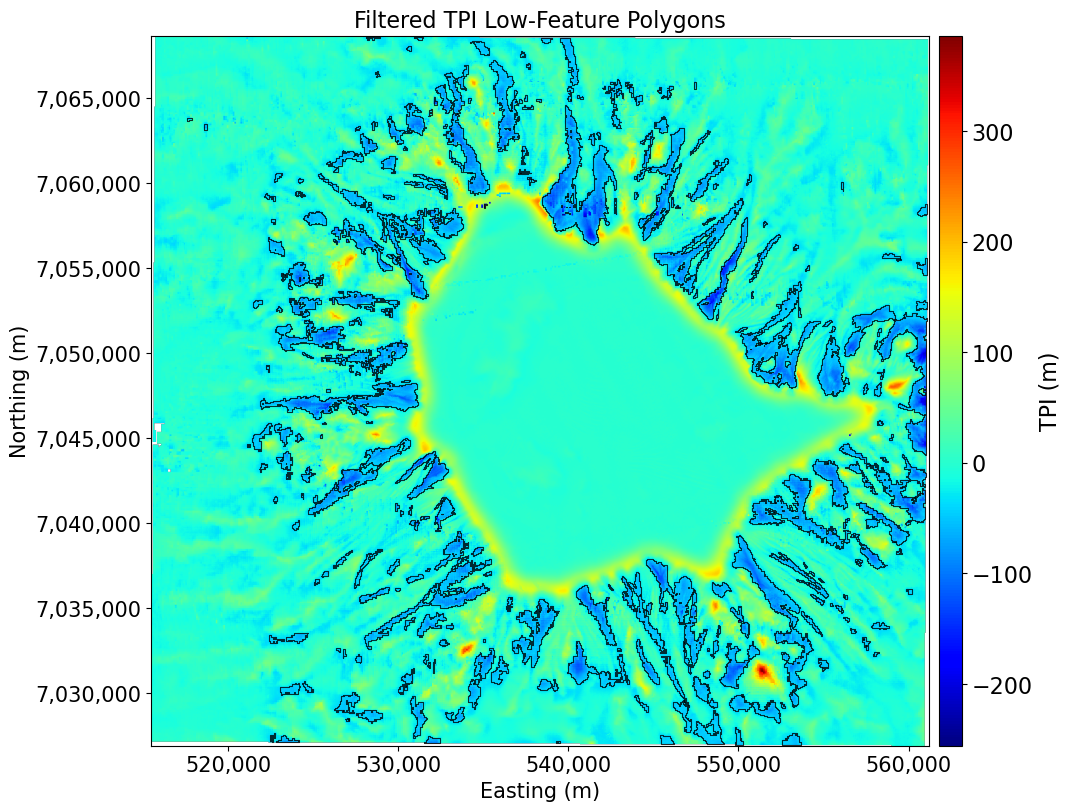

In [51]:
#%% Low-Feature Polygon Visualization
# -----------------------------------

fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True
)

# Display TPI raster as background
im_tpi = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="jet"
)

# Plot FILTERED low-feature polygons
if len(gdf_low_filtered):

    gdf_low_filtered.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.8
    )

ax.set_title(
    "Filtered TPI Low-Feature Polygons",
    fontsize=16
)

ax.set_xlabel(
    "Easting (m)",
    fontsize=15
)

ax.set_ylabel(
    "Northing (m)",
    fontsize=15
)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

ax.tick_params(
    axis="both",
    labelsize=15
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.1
)

cbar = fig.colorbar(
    im_tpi,
    cax=cax
)

cbar.set_label(
    "TPI (m)",
    fontsize=16
)

cbar.ax.tick_params(
    labelsize=16
)

plt.show()

# Final Interpretation and Connection to the Paper Workflow

The final output consists of bathymetric high-feature and low-feature polygons derived from the Topographic Position Index (TPI).

Positive TPI values identify areas that are elevated relative to their surroundings, while negative TPI values identify local depressions. Applying statistical thresholds isolates the most significant features, and polygonization converts those raster-based regions into discrete vector features.

After area filtering, the remaining polygons represent the most prominent seabed structures within the study area while reducing the influence of small, isolated features and noise.

These polygons can be used for:

- geomorphic classification
- spatial analysis
- further geomorphological interpretation

This section implements the complete TPI polygonization workflow described in the reference paper:

1. Calculate a TPI raster from the bathymetry data.
2. Compute TPI statistics and threshold values.
3. Identify bathymetric high and low features using thresholded TPI values.
4. Convert thresholded raster regions into polygons.
5. Remove small polygons using an area threshold.

The resulting polygons represent the final mapped bathymetric features and demonstrate the transition from raster-based analysis to vector-based geomorphic mapping.

As noted in the paper, the TPI Circle Radius, TPI STD Scale, and Area Threshold parameters all influence the mapping results. Different parameter combinations may highlight different seabed features, and multiple TPI radii are often required to capture seabed morphology occurring at different spatial scales.

# References

Huang, Z., Nanson, R., McNeil, M., Wenderlich, M., Gafeira, J., Post, A. L., & Nichol, S. L. (2023). Rule-based semi-automated tools for mapping seabed morphology from bathymetry data. Frontiers in Marine Science, 10. https://doi.org/10.3389/fmars.2023.1236788

‌

---

# III. TPI and Local Moran’s I (LMI) Expansion

TPI identifies the core of bathymetric high features, but it often only captures the most prominent part of a structure.

To better represent full geomorphic features, we extend TPI using Local Moran’s I (LMI), which identifies spatial clustering of similar values.

In this workflow:

- TPI defines feature cores (strong local highs)
- LMI expands these cores by finding connected high-value clusters

This produces more complete and spatially consistent seabed features.

## Removing the TPI Core

We remove the TPI core from the bathymetry before computing LMI.

This ensures LMI focuses on surrounding spatial structure rather than re-detecting the same core.

# Imports 

In [56]:
import numpy as np
from scipy import ndimage
import rasterio.features as rfeatures
from shapely.geometry import shape
import geopandas as gpd

Z = bathy.copy()

valid_Z = np.isfinite(Z)
valid_core = valid_Z & tpi_core_mask

Z_lmi = Z.copy()
Z_lmi[valid_core] = np.nan